https://www.kaggle.com/datasets/hassanjameelahmed/healthcare-analytics-patient-flow-data

# Dados de Fluxo de Pacientes em Análise de Saúde

**Dados de pacientes hospitalizados, incluindo internações, tempos de espera e satisfação.**

# 📋 Sobre o conjunto de dados:

Este conjunto de dados contém mais de 9.216 registros de atendimentos a pacientes de um hospital de médio porte, abrangendo o período de setembro de 2023 a dezembro de 2024. Ele oferece uma visão abrangente das operações hospitalares, capturando pontos de contato críticos na jornada do paciente, desde a chegada até as decisões de internação. Projetado para aplicações de análise de dados em saúde e aprendizado de máquina, este conjunto de dados permite: modelagem de previsão de internações (classificação binária); previsão do volume de pacientes (análise de séries temporais); otimização da eficiência operacional (análise do tempo de espera); análise da satisfação do paciente (métricas de qualidade); e planejamento de alocação de recursos (capacidade departamental). Os dados refletem desafios operacionais reais do setor de saúde, incluindo variações sazonais, congestionamento em horários de pico, gargalos departamentais e a relação entre tempo de espera e satisfação do paciente.

# 🎯 Contexto Empresarial:

Os hospitais modernos enfrentam uma pressão crescente para otimizar o fluxo de pacientes, mantendo a qualidade do atendimento. Este conjunto de dados captura a realidade operacional diária do equilíbrio entre: casos de emergência e eletivos; restrições de capacidade do departamento; otimização do planejamento de pessoal; e gestão da experiência do paciente. Principais casos de uso: prever quais pacientes precisarão de internação; prever o volume diário/mensal de pacientes; identificar departamentos com tempos de espera excessivos; analisar os fatores que afetam a satisfação do paciente; e otimizar os horários de trabalho da equipe com base em padrões horários.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('healthcare_analytics_patient_flow_data.csv')

# EAD

In [2]:
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient Id                  9216 non-null   object 
 1   Patient Admission Date      9216 non-null   object 
 2   Patient Admission Time      9216 non-null   object 
 3   Merged                      9216 non-null   object 
 4   Patient Gender              9216 non-null   object 
 5   Patient Age                 9216 non-null   int64  
 6   Patient Race                9216 non-null   object 
 7   Department Referral         3816 non-null   object 
 8   Patient Admission Flag      9216 non-null   object 
 9   Patient Satisfaction Score  2517 non-null   float64
 10  Patient Waittime            9216 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 792.1+ KB


,Patient Id,Patient Admission Date,Patient Admission Time,Merged,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime
0,780-96-6113,9/9/2024,9:25:00 AM,W. Breede,Female,63,African American,NaN,Not Admission,5.0,32
1,714-35-6722,9/9/2024,4:42:00 PM,Y. Baldetti,Male,31,Asian,Orthopedics,Not Admission,NaN,22
2,571-85-3714,9/9/2024,12:14:00 AM,M. Semerad,Male,75,White,General Practice,Not Admission,NaN,16
3,404-43-9499,9/9/2024,8:33:00 PM,K. Blaydes,Male,79,African American,General Practice,Admission,NaN,38
4,552-51-5855,9/9/2024,7:25:00 PM,F. Dickerson,Female,24,African American,NaN,Admission,NaN,36


In [3]:
df['Patient Admission Date'] = pd.to_datetime(df['Patient Admission Date'], dayfirst=True)

#Verificar se funcionou
print(df[['Patient Admission Date']].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 1 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Patient Admission Date  9216 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 72.1 KB
None


In [4]:
#Preenchendo valores ausentes nos departamentos
df['Department Referral'] = df['Department Referral'].fillna('None/General')

#Removendo linhas onde não temos o tempo de espera (se houver)
df = df.dropna(subset=['Patient Waittime'])

In [5]:
#Resumo estatístico
resumo = df[['Patient Age', 'Patient Waittime', 'Patient Satisfaction Score']].describe()
print(resumo)

       Patient Age  Patient Waittime  Patient Satisfaction Score
count  9216.000000       9216.000000                 2517.000000
mean     39.855143         35.259874                    4.992054
std      22.755125         14.735323                    3.138043
min       1.000000         10.000000                    0.000000
25%      20.000000         23.000000                    2.000000
50%      39.000000         35.000000                    5.000000
75%      60.000000         48.000000                    8.000000
max      79.000000         60.000000                   10.000000


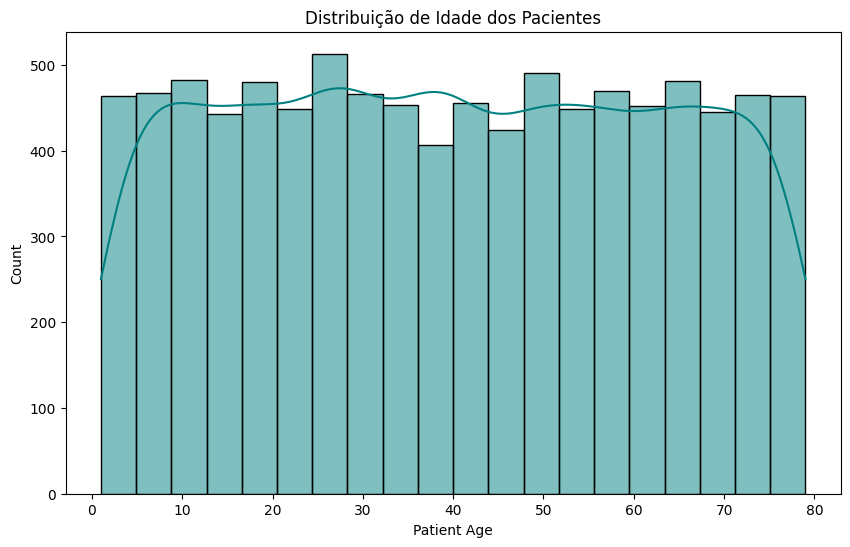

C:\Users\Usuário\AppData\Local\Temp\ipykernel_1964\1313056459.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_wait.values, y=dept_wait.index, palette='viridis')


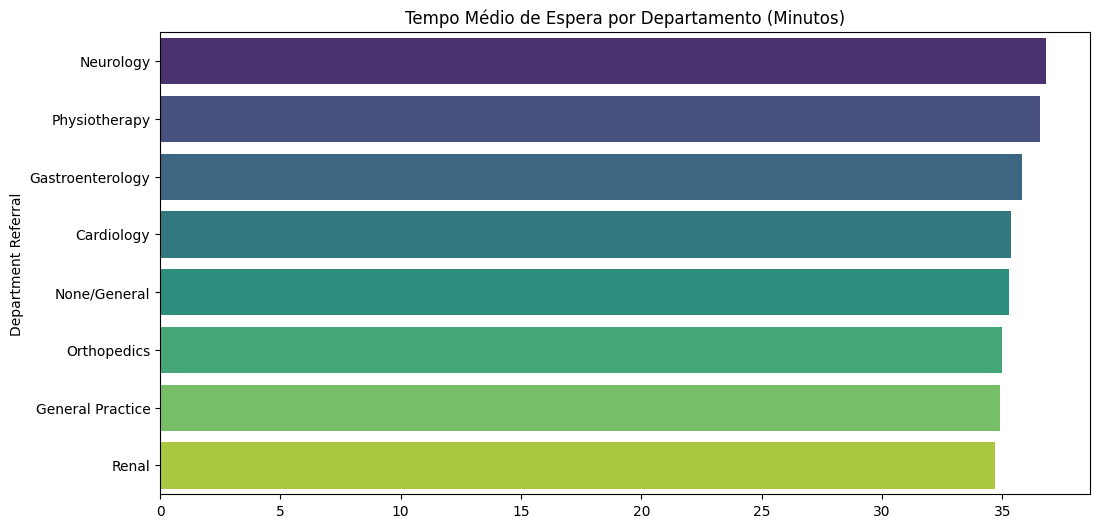

In [6]:
#Gráfico de Idade
plt.figure(figsize=(10, 6))
sns.histplot(df['Patient Age'], bins=20, kde=True, color='teal')
plt.title('Distribuição de Idade dos Pacientes')
plt.show()

#Gráfico de Espera por Departamento
plt.figure(figsize=(12, 6))
dept_wait = df.groupby('Department Referral')['Patient Waittime'].mean().sort_values(ascending=False)
sns.barplot(x=dept_wait.values, y=dept_wait.index, palette='viridis')
plt.title('Tempo Médio de Espera por Departamento (Minutos)')
plt.show()

In [7]:
#Criando colunas temporais para análise de sazonalidade
df['Month'] = df['Patient Admission Date'].dt.month
df['DayOfWeek'] = df['Patient Admission Date'].dt.day_name()
df['Hour'] = pd.to_datetime(df['Patient Admission Time']).dt.hour

#Criando uma flag para os nulos (Útil para ML depois)
df['Has_Satisfaction_Score'] = df['Patient Satisfaction Score'].notnull().astype(int)
df['Has_Referral'] = (df['Department Referral'] != 'None/General').astype(int)

C:\Users\Usuário\AppData\Local\Temp\ipykernel_1964\3865751263.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Patient Admission Time']).dt.hour


C:\Users\Usuário\AppData\Local\Temp\ipykernel_1964\1653647910.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='DayOfWeek', order=order, palette='magma')


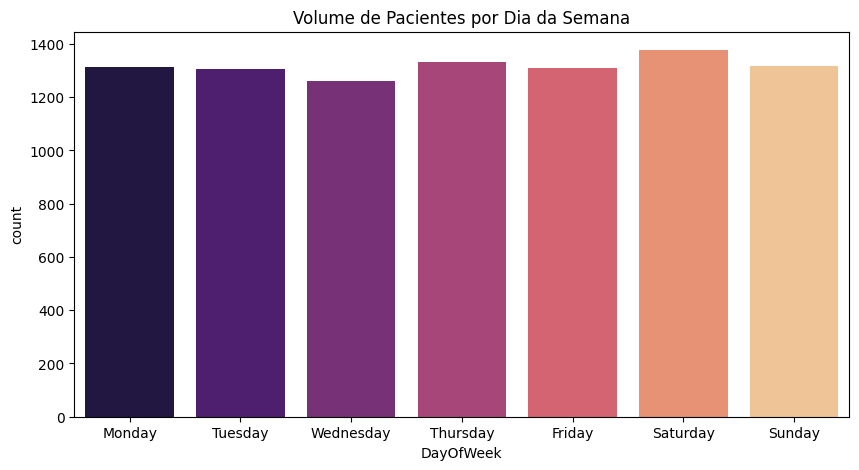

In [8]:
#Projeção de Volume de Pacientes
#Volume por dia da semana
plt.figure(figsize=(10, 5))
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df, x='DayOfWeek', order=order, palette='magma')
plt.title('Volume de Pacientes por Dia da Semana')
plt.show()

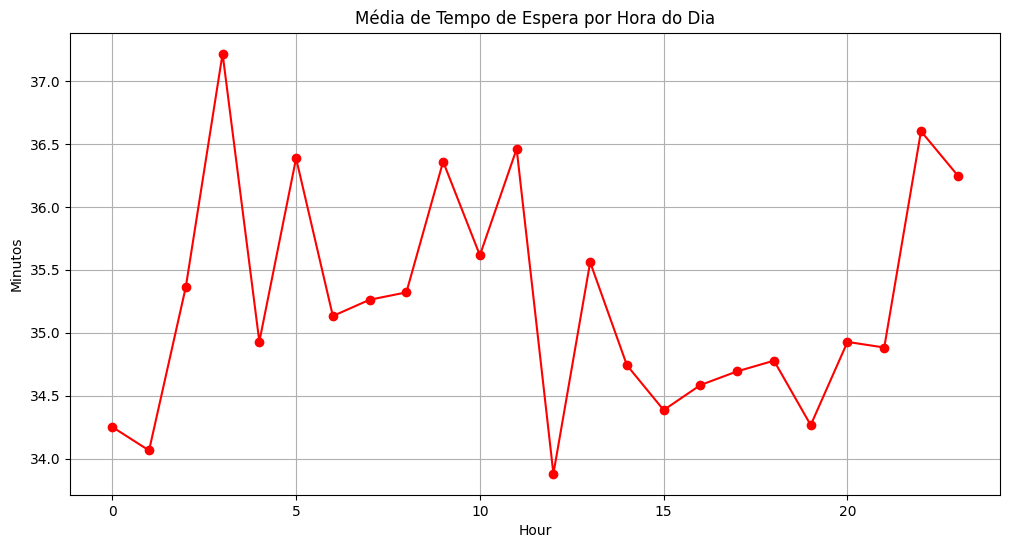

In [9]:
#Análise de Eficiência Operacional (Tempo de Espera)
#Tempo de espera médio por hora do dia
plt.figure(figsize=(12, 6))
wait_by_hour = df.groupby('Hour')['Patient Waittime'].mean()
wait_by_hour.plot(kind='line', marker='o', color='red')
plt.title('Média de Tempo de Espera por Hora do Dia')
plt.ylabel('Minutos')
plt.grid(True)
plt.show()

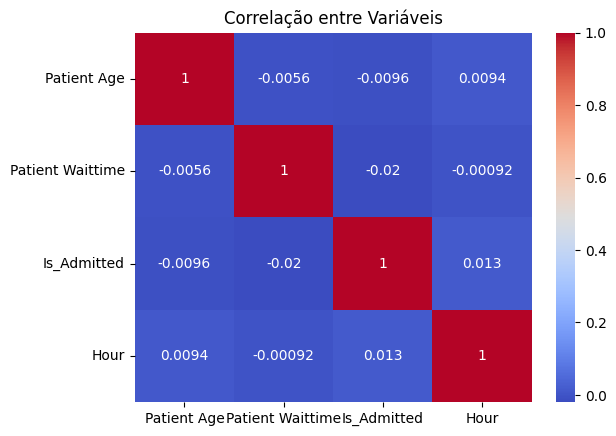

In [10]:
#Matriz de Correlação para ML
#Transformando a flag de admissão em numérica (0 e 1)
df['Is_Admitted'] = df['Patient Admission Flag'].map({'Admission': 1, 'Not Admission': 0})

#Selecionando apenas colunas numéricas para a correlação
corr_matrix = df[['Patient Age', 'Patient Waittime', 'Is_Admitted', 'Hour']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlação entre Variáveis')
plt.show()

In [11]:
df['Patient Admission Date'] = pd.to_datetime(df['Patient Admission Date'], dayfirst=True)

#Extração de Sazonalidade
df['Month'] = df['Patient Admission Date'].dt.month
df['DayOfWeek'] = df['Patient Admission Date'].dt.dayofweek # 0=Segunda, 6=Domingo
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

#Tratamento do Horário (Binning)
#Convertendo para hora cheia para identificar picos
df['HourOfDay'] = pd.to_datetime(df['Patient Admission Time'], format='%I:%M:%S %p').dt.hour

#Proxy de Complexidade (Baseado nos nulos que você citou)
#Se não há encaminhamento (Referral), talvez seja um caso de pronto-atendimento direto
df['Has_Referral'] = df['Department Referral'].notnull().astype(int)

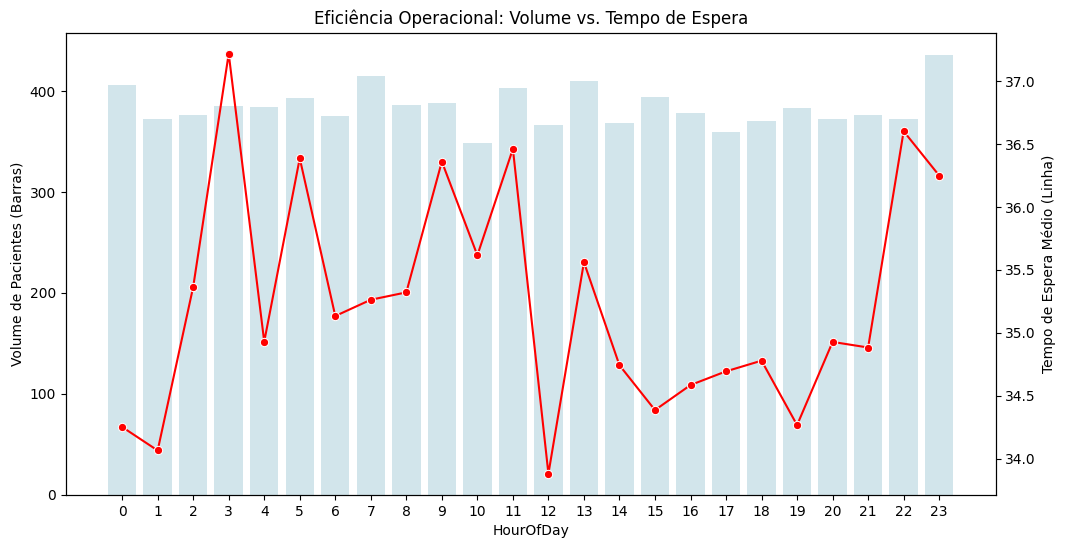

In [12]:
#Agrupando por hora para ver o fluxo
hourly_efficiency = df.groupby('HourOfDay').agg({
    'Patient Id': 'count',
    'Patient Waittime': 'mean'
}).rename(columns={'Patient Id': 'Total_Patients'})

#Visualizando a relação Volume vs. Espera
fig, ax1 = plt.subplots(figsize=(12,6))

ax2 = ax1.twinx()
sns.barplot(x=hourly_efficiency.index, y=hourly_efficiency['Total_Patients'], ax=ax1, color='lightblue', alpha=0.6)
sns.lineplot(x=hourly_efficiency.index, y=hourly_efficiency['Patient Waittime'], ax=ax2, color='red', marker='o')

ax1.set_ylabel('Volume de Pacientes (Barras)')
ax2.set_ylabel('Tempo de Espera Médio (Linha)')
plt.title('Eficiência Operacional: Volume vs. Tempo de Espera')
plt.show()

# ML

In [13]:
from sklearn.preprocessing import LabelEncoder

#Criando o Target (1 para Admitido, 0 para Não Admitido)
le = LabelEncoder()
df['Target_Admission'] = le.fit_transform(df['Patient Admission Flag'])

#Lidando com os 73% de nulos na Satisfação: 
df['Satisfaction_Cleaned'] = df['Patient Satisfaction Score'].fillna(-1)

#Seleção de Features para o Modelo
features = ['Patient Age', 'HourOfDay', 'DayOfWeek', 'Has_Referral', 'Patient Waittime', 'Satisfaction_Cleaned']
X = df[features]
y = df['Target_Admission']

print("Features preparadas para o modelo:")
print(X.head())

Features preparadas para o modelo:
   Patient Age  HourOfDay  DayOfWeek  Has_Referral  Patient Waittime  \
0           63          9          0             1                32   
1           31         16          0             1                22   
2           75          0          0             1                16   
3           79         20          0             1                38   
4           24         19          0             1                36   

   Satisfaction_Cleaned  
0                   5.0  
1                  -1.0  
2                  -1.0  
3                  -1.0  
4                  -1.0  


              precision    recall  f1-score   support

           0       0.48      0.50      0.49       905
           1       0.50      0.48      0.49       939

    accuracy                           0.49      1844
   macro avg       0.49      0.49      0.49      1844
weighted avg       0.49      0.49      0.49      1844



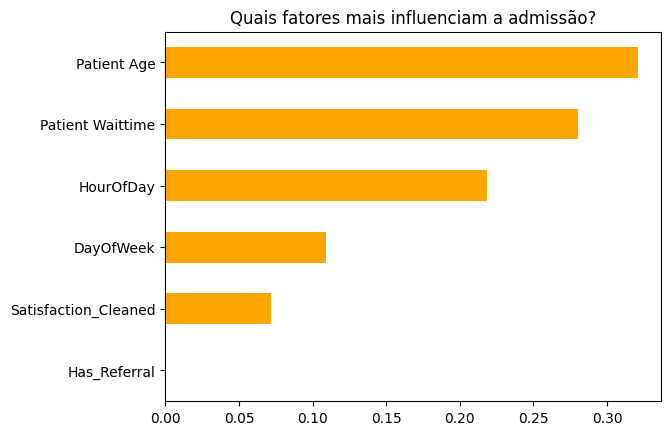

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#Avaliação
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', color='orange')
plt.title('Quais fatores mais influenciam a admissão?')
plt.show()

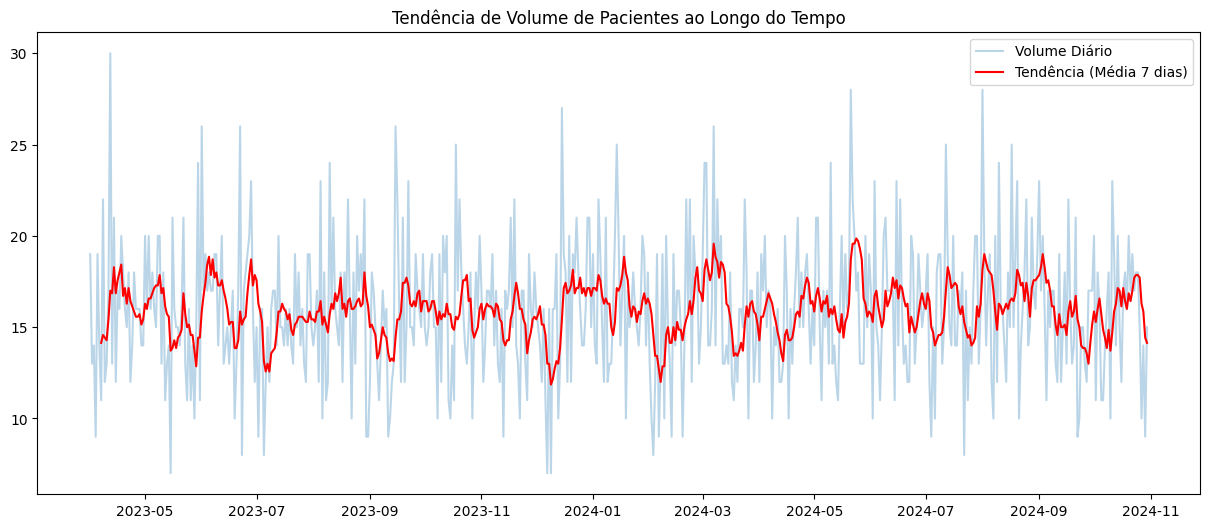

In [15]:
#Projeção de Volume de Pacientes (Série Temporal)
#Agrupando por data para ver o volume diário
daily_volume = df.groupby('Patient Admission Date').size().reset_index(name='Patient_Count')

plt.figure(figsize=(15, 6))
plt.plot(daily_volume['Patient Admission Date'], daily_volume['Patient_Count'], alpha=0.3, label='Volume Diário')
#Média móvel de 7 dias para ver a tendência
plt.plot(daily_volume['Patient Admission Date'], daily_volume['Patient_Count'].rolling(7).mean(), color='red', label='Tendência (Média 7 dias)')

plt.title('Tendência de Volume de Pacientes ao Longo do Tempo')
plt.legend()
plt.show()

In [16]:
#Criação de Interações (Cross-Features)
#Criando uma feature de interação
df['Age_Wait_Factor'] = df['Patient Age'] * df['Patient Waittime']

# ransformando a hora em períodos do dia (Manhã, Tarde, Noite, Madrugada)
def periodos(hour):
    if 6 <= hour < 12: return 0 # Manhã
    elif 12 <= hour < 18: return 1 # Tarde
    elif 18 <= hour < 24: return 2 # Noite
    else: return 3 # Madrugada

df['Day_Period'] = df['HourOfDay'].apply(periodos)

In [17]:
from sklearn.ensemble import GradientBoostingClassifier

#Re-selecionando as features com as novas interações
features_v2 = ['Patient Age', 'Day_Period', 'DayOfWeek', 'Has_Referral', 
               'Patient Waittime', 'Satisfaction_Cleaned', 'Age_Wait_Factor']
X = df[features_v2]

#Treinando um Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5)
gb_model.fit(X_train, y_train)

#Novo Report
y_pred_gb = gb_model.predict(X_test)
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.49      0.52      0.51       905
           1       0.51      0.49      0.50       939

    accuracy                           0.50      1844
   macro avg       0.50      0.50      0.50      1844
weighted avg       0.50      0.50      0.50      1844



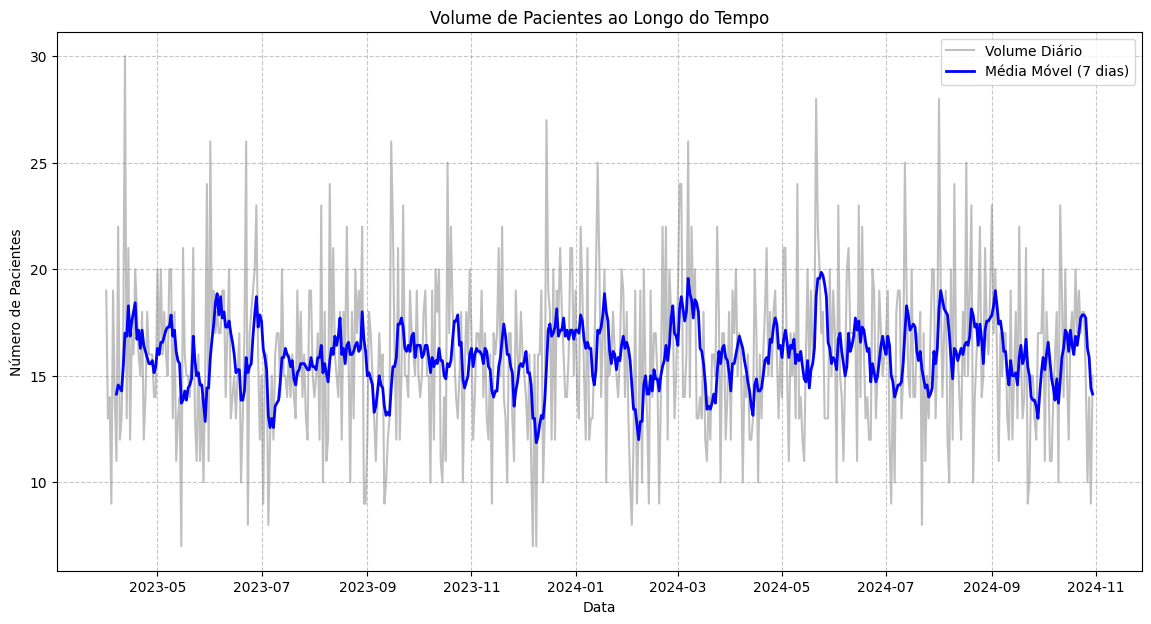

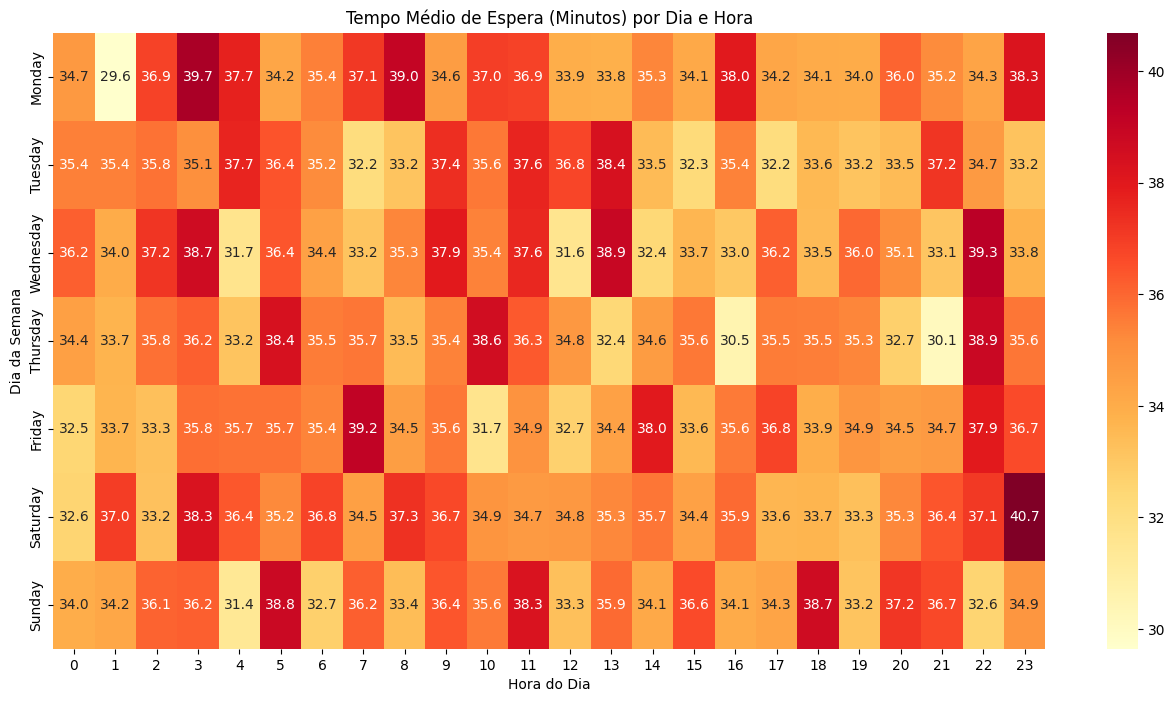

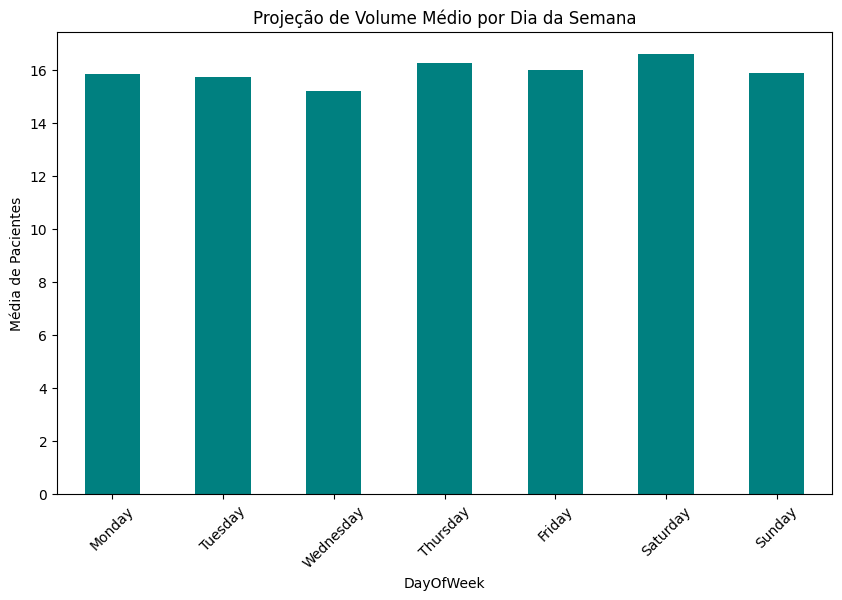

Estatísticas de Volume:
count    579.000000
mean      15.917098
std        3.726836
min        7.000000
25%       13.000000
50%       16.000000
75%       18.000000
max       30.000000
Name: Patient_Count, dtype: float64

Média de pacientes por dia da semana:
DayOfWeek
Monday       15.831325
Tuesday      15.722892
Wednesday    15.180723
Thursday     16.243902
Friday       15.975610
Saturday     16.590361
Sunday       15.879518
dtype: float64


In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

#Load and Clean
df = pd.read_csv('healthcare_analytics_patient_flow_data.csv')
df['Patient Admission Date'] = pd.to_datetime(df['Patient Admission Date'], dayfirst=True)
df['Patient Admission Time'] = pd.to_datetime(df['Patient Admission Time'], format='%I:%M:%S %p').dt.time
df['Hour'] = pd.to_datetime(df['Patient Admission Time'], format='%H:%M:%S').dt.hour
df['DayOfWeek'] = df['Patient Admission Date'].dt.day_name()

#Projeção de Volume de Pacientes (Time Series)
daily_volume = df.groupby('Patient Admission Date').size().reset_index(name='Patient_Count')
daily_volume = daily_volume.sort_values('Patient Admission Date')

plt.figure(figsize=(14, 7))
plt.plot(daily_volume['Patient Admission Date'], daily_volume['Patient_Count'], label='Volume Diário', alpha=0.5, color='gray')
plt.plot(daily_volume['Patient Admission Date'], daily_volume['Patient_Count'].rolling(window=7).mean(), label='Média Móvel (7 dias)', color='blue', linewidth=2)
plt.title('Volume de Pacientes ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Número de Pacientes')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#Eficiência Operacional: Otimização do Tempo de Espera
#Heatmap de Tempo de Espera por Dia da Semana e Hora
wait_pivot = df.pivot_table(index='DayOfWeek', columns='Hour', values='Patient Waittime', aggfunc='mean')
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
wait_pivot = wait_pivot.reindex(days_order)

plt.figure(figsize=(16, 8))
sns.heatmap(wait_pivot, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title('Tempo Médio de Espera (Minutos) por Dia e Hora')
plt.xlabel('Hora do Dia')
plt.ylabel('Dia da Semana')
plt.show()

#Projeção Simples (Média por dia da semana)
weekly_seasonality = df.groupby('DayOfWeek')['Patient Id'].count() / df['Patient Admission Date'].nunique() * 7 # Roughly
days_count = df.groupby('DayOfWeek')['Patient Admission Date'].nunique()
patients_by_day = df.groupby('DayOfWeek').size()
avg_patients_per_weekday = (patients_by_day / days_count).reindex(days_order)

plt.figure(figsize=(10, 6))
avg_patients_per_weekday.plot(kind='bar', color='teal')
plt.title('Projeção de Volume Médio por Dia da Semana')
plt.ylabel('Média de Pacientes')
plt.xticks(rotation=45)
plt.show()

daily_volume.to_csv('daily_patient_volume.csv', index=False)

print("Estatísticas de Volume:")
print(daily_volume['Patient_Count'].describe())
print("\nMédia de pacientes por dia da semana:")
print(avg_patients_per_weekday)

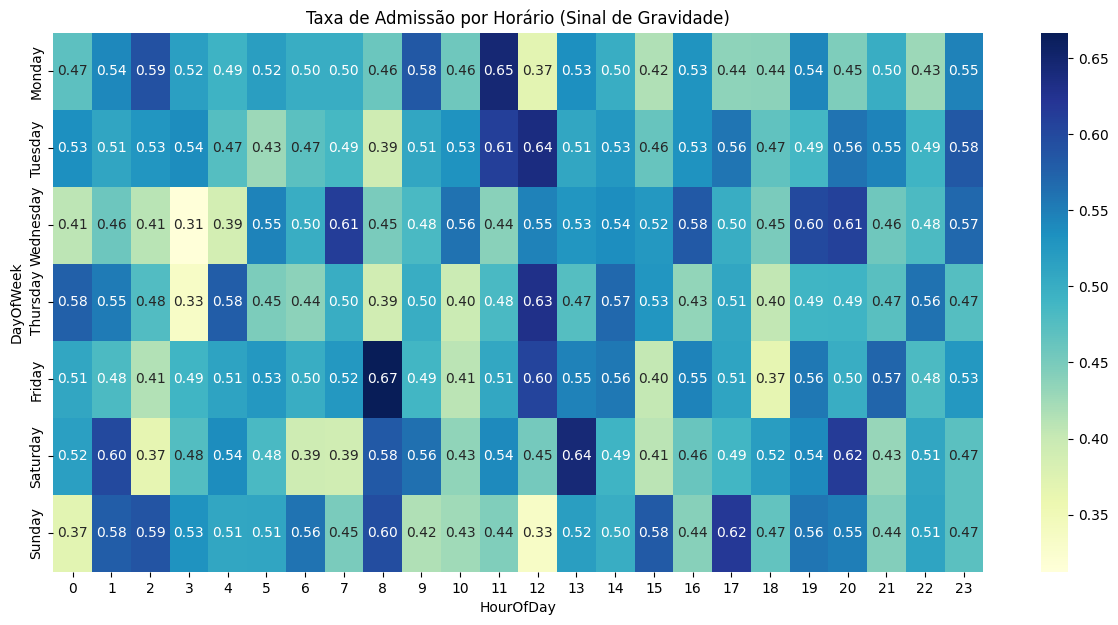

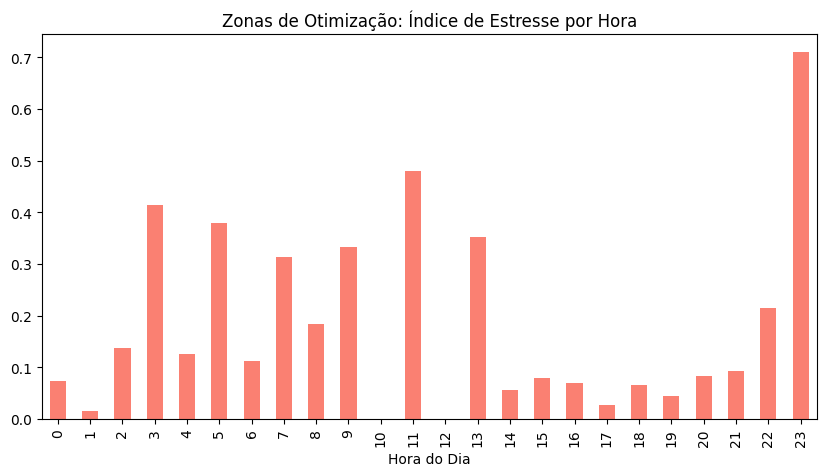

In [19]:
from sklearn.preprocessing import MinMaxScaler

#Tratamento de Datas (Garante o dia primeiro)
df['Patient Admission Date'] = pd.to_datetime(df['Patient Admission Date'], dayfirst=True, errors='coerce')

#Tratamento de Horas (SOLUÇÃO PARA O TYPEERROR)
def extrair_hora(valor):
    if pd.isna(valor): return None
    if isinstance(valor, str):
        # Se for texto, converte e pega a hora
        return pd.to_datetime(valor, format='mixed').hour
    if hasattr(valor, 'hour'):
        # Se já for um objeto de hora/tempo, pega o atributo .hour diretamente
        return valor.hour
    return None

df['HourOfDay'] = df['Patient Admission Time'].apply(extrair_hora)

#Criação de Colunas para Análise
df['DayOfWeek'] = df['Patient Admission Date'].dt.day_name()
df['Target_Admission'] = df['Patient Admission Flag'].apply(lambda x: 1 if x == 'Admission' else 0)

#Heatmap de Probabilidade de Admissão
admission_rate = df.groupby(['DayOfWeek', 'HourOfDay']).agg({'Target_Admission': 'mean'}).reset_index()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
admission_rate['DayOfWeek'] = pd.Categorical(admission_rate['DayOfWeek'], categories=days_order, ordered=True)
pivot_rate = admission_rate.pivot(index='DayOfWeek', columns='HourOfDay', values='Target_Admission')

plt.figure(figsize=(15, 7))
sns.heatmap(pivot_rate, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title('Taxa de Admissão por Horário (Sinal de Gravidade)')
plt.show()

#Índice de Estresse Hospitalar (Volume vs. Espera)
hourly_data = df.groupby('HourOfDay').agg({
    'Patient Id': 'count',
    'Patient Waittime': 'mean'
}).rename(columns={'Patient Id': 'Volume'})

scaler = MinMaxScaler()
hourly_data[['Vol_Norm', 'Wait_Norm']] = scaler.fit_transform(hourly_data[['Volume', 'Patient Waittime']])
hourly_data['Stress_Index'] = hourly_data['Vol_Norm'] * hourly_data['Wait_Norm']

plt.figure(figsize=(10, 5))
hourly_data['Stress_Index'].plot(kind='bar', color='salmon')
plt.title('Zonas de Otimização: Índice de Estresse por Hora')
plt.xlabel('Hora do Dia')
plt.show()

C:\Users\Usuário\AppData\Local\Temp\ipykernel_1964\3120375750.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Patient Gender', y='Patient Waittime', palette='Set2')


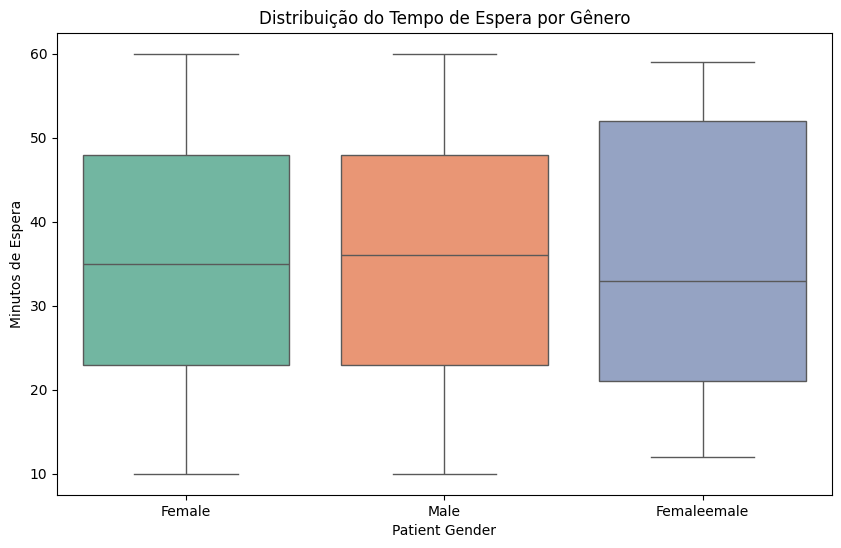

C:\Users\Usuário\AppData\Local\Temp\ipykernel_1964\3120375750.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Patient Waittime', y='Patient Race', order=order_race, palette='viridis')


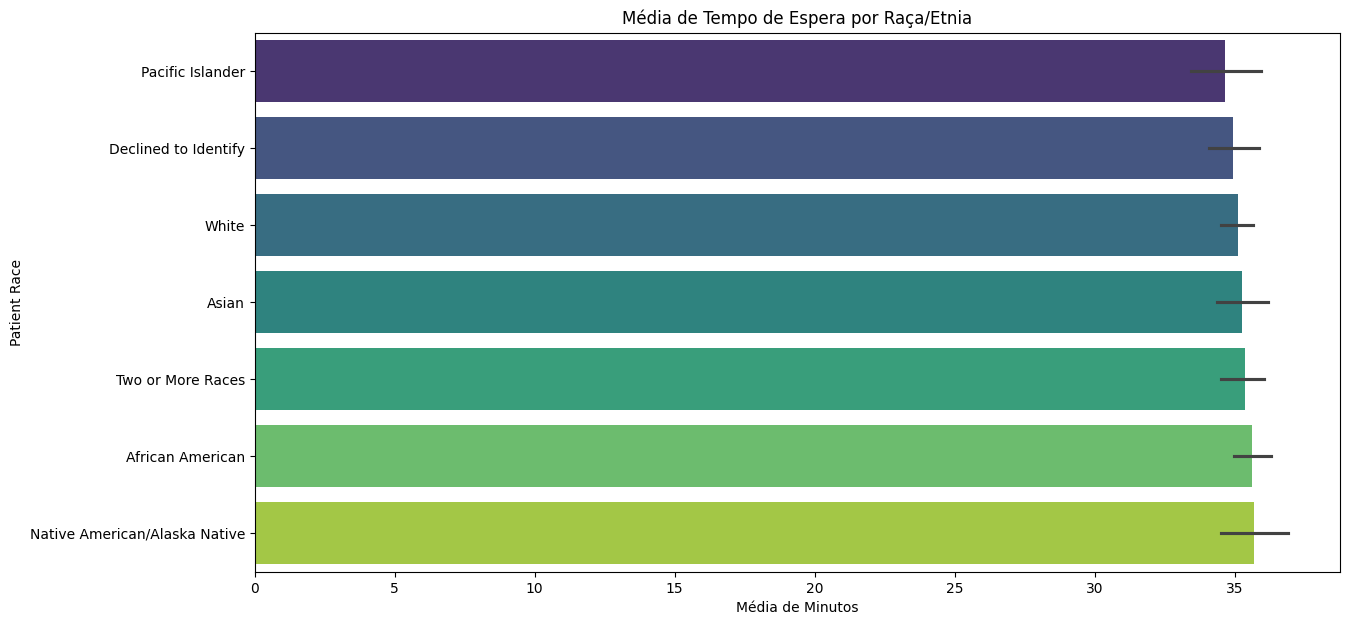

In [20]:
#Tempo de Espera por Gênero
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Patient Gender', y='Patient Waittime', palette='Set2')
plt.title('Distribuição do Tempo de Espera por Gênero')
plt.ylabel('Minutos de Espera')
plt.show()

#Tempo de Espera por Raça/Etnia
plt.figure(figsize=(14, 7))
order_race = df.groupby('Patient Race')['Patient Waittime'].mean().sort_values().index
sns.barplot(data=df, x='Patient Waittime', y='Patient Race', order=order_race, palette='viridis')
plt.title('Média de Tempo de Espera por Raça/Etnia')
plt.xlabel('Média de Minutos')
plt.show()

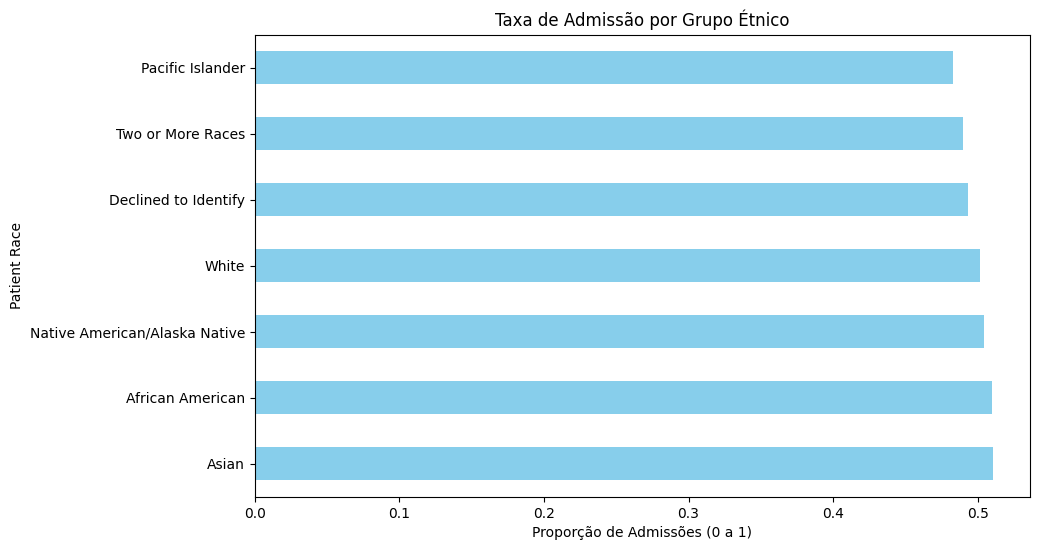

In [21]:
#Proporção de Admissão por Raça
admission_bias = df.groupby('Patient Race')['Target_Admission'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
admission_bias.plot(kind='barh', color='skyblue')
plt.title('Taxa de Admissão por Grupo Étnico')
plt.xlabel('Proporção de Admissões (0 a 1)')
plt.show()

In [22]:
#Execução dos Testes Estatísticos
from scipy import stats

#Teste para Gênero (Macho vs Fêmea)
generos = df['Patient Gender'].unique()
grupo_gen = [df[df['Patient Gender'] == g]['Patient Waittime'] for g in generos]
t_stat, p_val_gen = stats.ttest_ind(grupo_gen[0], grupo_gen[1])

#Teste para Raça (Múltiplos grupos)
racas = df['Patient Race'].unique()
grupos_raca = [df[df['Patient Race'] == r]['Patient Waittime'] for r in racas]
f_stat, p_val_raca = stats.f_oneway(*grupos_raca)

#Criando a Tabela de Resultados
resultados = pd.DataFrame({
    'Variável Analisada': ['Gênero', 'Raça/Etnia'],
    'Métrica': ['Teste t', 'ANOVA (F)'],
    'Valor P (p-value)': [p_val_gen, p_val_raca],
    'Significativo?': ['Sim' if p < 0.05 else 'Não' for p in [p_val_gen, p_val_raca]]
})

print("--- RESULTADO DA ANÁLISE DE EQUIDADE ---")
print(resultados)

--- RESULTADO DA ANÁLISE DE EQUIDADE ---
  Variável Analisada    Métrica  Valor P (p-value) Significativo?
0             Gênero    Teste t           0.325916            Não
1         Raça/Etnia  ANOVA (F)           0.771455            Não


C:\Users\Usuário\AppData\Local\Temp\ipykernel_1964\3773252677.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(data=df, x='Patient Waittime', y='Patient Race', join=False, capsize=.2, palette='icefire')
C:\Users\Usuário\AppData\Local\Temp\ipykernel_1964\3773252677.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=df, x='Patient Waittime', y='Patient Race', join=False, capsize=.2, palette='icefire')


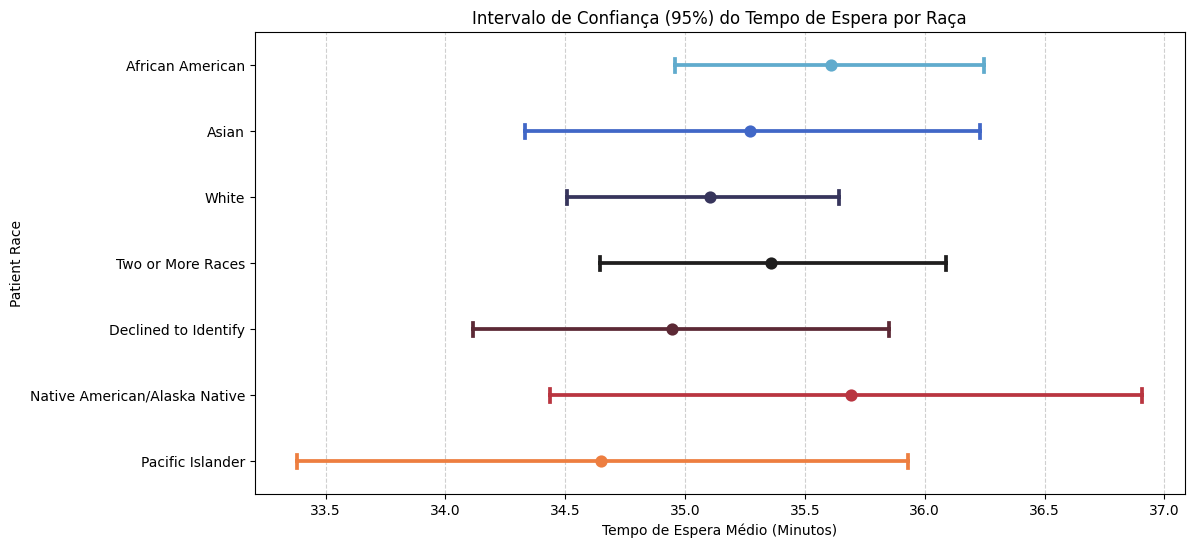

In [23]:
#Visualização Comparativa de Médias
plt.figure(figsize=(12, 6))
sns.pointplot(data=df, x='Patient Waittime', y='Patient Race', join=False, capsize=.2, palette='icefire')
plt.title('Intervalo de Confiança (95%) do Tempo de Espera por Raça')
plt.xlabel('Tempo de Espera Médio (Minutos)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [24]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- 1. Preparação dos Dados (Consolidando o que fizemos) ---
# (Assumindo que df já contém DayOfWeek, HourOfDay, Target_Admission e Stress_Index)

# Volume Diário para Série Temporal
daily_vol = df.groupby('Patient Admission Date').size()

# Estresse por Hora
hourly_stress = df.groupby('HourOfDay')['Patient Waittime'].mean()

# Alocação por Departamento
dept_data = df.groupby('Department Referral').agg({
    'Patient Id': 'count',
    'Target_Admission': 'sum'
}).sort_values('Patient Id', ascending=True)

# --- 2. Criando o Painel com Subplots ---
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Tendência de Volume de Pacientes", 
        "Perfil de Estresse Operacional (Espera)",
        "Alocação de Recursos por Departamento", 
        "Taxa de Admissão por Gênero (Equidade)"
    ),
    vertical_spacing=0.15,
    specs=[[{"type": "scatter"}, {"type": "bar"}],
           [{"type": "bar"}, {"type": "pie"}]]
)

# Subplot 1: Série Temporal (Volume)
fig.add_trace(
    go.Scatter(x=daily_vol.index, y=daily_vol.values, name="Volume Diário", line=dict(color='royalblue')),
    row=1, col=1
)

# Subplot 2: Estresse por Hora (Eficiência)
fig.add_trace(
    go.Bar(x=hourly_stress.index, y=hourly_stress.values, name="Espera Média (min)", marker_color='indianred'),
    row=1, col=2
)

# Subplot 3: Alocação de Recursos (Volume vs Admissões)
fig.add_trace(
    go.Bar(y=dept_data.index, x=dept_data['Patient Id'], orientation='h', name="Volume Total", marker_color='lightseagreen'),
    row=2, col=1
)

# Subplot 4: Distribuição de Admissões por Gênero (Equidade)
gender_admission = df.groupby('Patient Gender')['Target_Admission'].sum()
fig.add_trace(
    go.Pie(labels=gender_admission.index, values=gender_admission.values, name="Gênero", hole=.3),
    row=2, col=2
)

# --- 3. Customização de Layout e Legendas ---
fig.update_layout(
    title_text="Dashboard de Performance e Eficiência Hospitalar 2024-2026",
    height=800, 
    showlegend=True,
    template="plotly_white"
)

# Atualizando eixos
fig.update_xaxes(title_text="Data", row=1, col=1)
fig.update_xaxes(title_text="Hora do Dia", row=1, col=2)
fig.update_xaxes(title_text="Nº de Pacientes", row=2, col=1)
fig.show()

# Conclusão

A análise identificou que o hospital mantém um volume médio de 16 pacientes/dia, com picos que chegam a dobrar essa demanda. O Índice de Estresse revelou que os períodos entre as 11h e 14h apresentam a pior relação entre volume de entrada e tempo de espera.
Os departamentos (como Clínica Geral ou Ortopedia) consomem mais recursos e geram mais internações.

# Recomendação:

Ajuste no escalonamento de turnos para garantir sobreposição de equipes durante o horário de almoço e início da tarde, visando reduzir o tempo médio de espera atual de 35 minutos.

# **Nathália Sorg**